In [1]:
include("BarrierSynthesis.jl")
# include("PlotBarriers.jl")

compute_next_level_barriersPM (generic function with 1 method)

In [2]:
@polyvar u[1:1]
@polyvar(x[1:4]) # x[1] is x, x[2] is y, x[3] is θ, x[4] is error
v = 0.9
    dynamics = [
        (ctrl -> [v*(2.0/π)*(x[3] + π/2.0)-0.2x[4],v*(-2.0/π)*(x[3]+π)-0.2x[4], ctrl[1], 0.]),
        (ctrl -> [v*(2.0/π)*(x[3] + π/2.0)-0.2x[4],v*(2.0/π)*x[3]+0.2x[4], ctrl[1], 0]),
        (ctrl -> [v*(-2.0/π)*(x[3] - π/2.0)+0.2x[4],v*(2.0/π)*x[3]+0.2x[4], ctrl[1], 0]),
        (ctrl -> [v*(-2.0/π)*(x[3] - π/2.0)+0.2x[4],v*(-2.0/π)*(x[3]-π)-0.2x[4], ctrl[1], 0]),
    ]
g = 0.1^2 - x[1]^2 - x[2]^2 # Obstacle: is a (x,y) ball of radius 0.1 around origin
bounds = [[-10., 10.], [-10., 10.], [-π,π], [-1.,1.]]

4-element Vector{Vector{Float64}}:
 [-10.0, 10.0]
 [-10.0, 10.0]
 [-3.141592653589793, 3.141592653589793]
 [-1.0, 1.0]

In [3]:
K = 1.0
δ = 1.0
τ = 0.12
ϵ = 0.1
α = 0.6
max_degree=4
# Synthesis control set should match simulation actuation limits.
U = [[-7.0], [7.0]]
n_tests = 100

100

In [4]:
test_pts = [ get_random(bounds, g) for _ in 1:n_tests]

100-element Vector{Vector{Float64}}:
 [-9.346522785206803, -7.491620081094528, 1.9836067063738891, -0.6509739854668213]
 [3.841959670612347, -2.0433136177393463, 1.5455331550206584, 0.4507491336150191]
 [1.2230248432603315, 6.128313921064773, -2.0862919407281177, -0.462420341915073]
 [-5.374644043081924, -1.9188707897301072, 1.6973389883889558, 0.012201286632840036]
 [3.133337880797299, 4.547698104304708, -0.5141359296087473, -0.9876342753172282]
 [-7.408344463930854, 2.047825741882628, 0.8586925256001514, 0.9422610740049984]
 [4.753805773927784, -4.560405205847166, -1.0155522964699681, 0.02873582576968481]
 [-9.784255266901045, 0.6497680142653088, 0.6527615395442532, -0.5643628744026972]
 [-4.641933366795621, -0.18706813961364332, -3.1115085178496735, -0.762418604071059]
 [7.512336963085943, -1.5151652609586375, -2.0321341493898757, -0.0504766539772501]
 [-4.796964751631503, -0.26495248493358403, 0.770738065991428, -0.4476622257522278]
 [-7.062203351219658, -2.0472205159971546, -2.173

In [5]:
function findRepulsiveBarrier_HybridDB(x, ctrl::Vector{Float64}, g, dynamics, test_pts; max_degree=4, ϵ=1.0, τ=0.1, γ=10.0, K=1.0, δ=1.0, α=1.0, state_bounds=bounds)
    function prepare_domain_hybrid(var, lb, ub)
        dom = @set(var >= lb) ∩ @set(var <= ub) ∩ @set((var - lb) * (ub - var) >= 0)
        return dom
    end
    
    @assert τ > 0.0 "τ must be positive."
    @assert δ > 0.0 "δ must be positive."
    @assert K >= 0.0 "K must be nonnegative."
    @assert α > 0.0 "α must be positive."

    λ = (1.0 / τ) * log(1.0 + K / δ)

    solver = optimizer_with_attributes(MosekTools.Optimizer)
    model = SOSModel(solver)

    monos = monomials(x, 0:max_degree)
    N = length(monos)
    @variable(model, -γ <= c[1:N] <= γ)
    B = polynomial(c[1:end], monos)

    dom_list = prepare_domain(x, state_bounds)
    D = reduce((s1, s2) -> s1 ∩ s2, dom_list)
    println("Domain: $D")

    # 1) Unsafe-set positivity on obstacle states (g >= 0 denotes the obstacle interior)
    @constraint(model, B >= ϵ, domain = D ∩ @set(g >= 0))

    # 2) Decrease condition under each hybrid mode and fixed control
    for (i, dyn_i) in enumerate(dynamics)
        dyn_with_ctrl = dyn_i(ctrl)
        dBdt = dot(differentiate(B, x), dyn_with_ctrl)
        dom_i = prepare_domain_hybrid(x[3], (i - 3) * π / 2, (i - 2) * π / 2)
        @constraint(model, dBdt <= λ * B, domain = D ∩ dom_i)
    end

    # 3) Bounded-jump condition: B(y - yo, z) - B(y, z) <= K for yo in obstacle set
    @polyvar q1 q2
    Qα = @set(α^2 - q1^2 - q2^2 >= 0)
    B_shift = subs(B, x[1] => x[1] - q1, x[2] => x[2] - q2)
    @constraint(model, K >= B_shift - B, domain = D ∩ Qα)

    # set_objective_sense(model, MOI.FEASIBILITY_SENSE)
    set_objective_sense(model, MOI.MIN_SENSE)
    objective_fn = sum((B(pt...) for pt in test_pts); init=0.0)
    # With unsafe encoded as B > 0, minimize B on test points to expand the certified safe set B <= 0.
    @objective(model, Min, objective_fn)

    JuMP.optimize!(model)
    stat = JuMP.primal_status(model)
    solution_summary(model)
    println("Status obtained: $(stat)")

    if stat != FEASIBLE_POINT
        return missing
    end

    return value(B), K
end

findRepulsiveBarrier_HybridDB (generic function with 1 method)

In [6]:
res_1 = findRepulsiveBarrier_HybridDB(x, U[1], g, dynamics, test_pts; ϵ, τ = τ, K = K, δ = δ, α = α, state_bounds = bounds)
@assert res_1 !== missing "Failed to synthesize barrier for U[1]"
B_1, K_1 = res_1
display(B_1)
display(K_1)
# Keep points not yet certified safe (B > 0) for subsequent barrier synthesis.
test_pts = filter!(pt -> B_1(pt...) > 0.0, test_pts)

Domain: { (x[1], x[2], x[3], x[4]) | 10.0 + x[1] ≥ 0, 10.0 - x[1] ≥ 0, 100.0 - x[1]^2 ≥ 0, 10.0 + x[2] ≥ 0, 10.0 - x[2] ≥ 0, 100.0 - x[2]^2 ≥ 0, 3.141592653589793 + x[3] ≥ 0, 3.141592653589793 - x[3] ≥ 0, 9.869604401089358 - x[3]^2 ≥ 0, 1.0 + x[4] ≥ 0, 1.0 - x[4] ≥ 0, 1.0 - x[4]^2 ≥ 0 }
Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 560             
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 70              
  Matrix variables       : 92 (scalarized: 2465)
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator started.
Freed constraints in eliminator : 0
Eliminator terminated.
Eliminator - tries                  : 1            

1.3659398991070242 + 0.015606790904070468x₄ - 0.7060233308900625x₃ + 0.011186336192959714x₂ - 0.06575797916616885x₁ + 0.0023125473283748905x₄² + 0.04635087121429226x₃x₄ + 0.21122583945905707x₃² - 0.008997460453984422x₂x₄ - 0.01684541185580353x₂x₃ - 0.033285533144532226x₂² + 0.0008453661940477645x₁x₄ + 0.05529914528074405x₁x₃ - 0.0018733329944035184x₁x₂ - 0.027954390857060255x₁² + 8.753966951168561e-5x₄³ + 0.0022600807464503276x₃x₄² + 0.015581146889936824x₃²x₄ + 0.11185561949353313x₃³ - 0.000453370246782655x₂x₄² + 0.0024257800395199487x₂x₃x₄ + 0.012286042492493893x₂x₃² - 0.0009892260034489301x₂²x₄ + 0.010747940784110439x₂²x₃ - 8.224248425020186e-5x₂³ - 0.00011068158651841552x₁x₄² - 0.0017295202956414974x₁x₃x₄ - 0.028518874936098424x₁x₃² + 0.0002361065813040076x₁x₂x₄ + 0.00033056851297356683x₁x₂x₃ + 0.0005843701650455644x₁x₂² - 0.0009079335233545582x₁²x₄ + 0.009061822635495693x₁²x₃ - 5.5623727257014836e-5x₁²x₂ + 0.0005215547341171653x₁³ + 0.00013583282934071848x₄⁴ - 6.906739089636855e-6x

1.0

73-element Vector{Vector{Float64}}:
 [-9.346522785206803, -7.491620081094528, 1.9836067063738891, -0.6509739854668213]
 [3.841959670612347, -2.0433136177393463, 1.5455331550206584, 0.4507491336150191]
 [1.2230248432603315, 6.128313921064773, -2.0862919407281177, -0.462420341915073]
 [-5.374644043081924, -1.9188707897301072, 1.6973389883889558, 0.012201286632840036]
 [3.133337880797299, 4.547698104304708, -0.5141359296087473, -0.9876342753172282]
 [-7.408344463930854, 2.047825741882628, 0.8586925256001514, 0.9422610740049984]
 [-9.784255266901045, 0.6497680142653088, 0.6527615395442532, -0.5643628744026972]
 [-4.641933366795621, -0.18706813961364332, -3.1115085178496735, -0.762418604071059]
 [-4.796964751631503, -0.26495248493358403, 0.770738065991428, -0.4476622257522278]
 [-7.062203351219658, -2.0472205159971546, -2.173426778237266, -0.5627761573156627]
 [3.200848303375949, 7.5778600691715035, 0.9051084813458186, 0.3549056563047963]
 [4.819316692888872, -1.1534401910931251, -0.0975505

In [7]:
res_2 = findRepulsiveBarrier_HybridDB(x, U[2], g, dynamics, test_pts; ϵ, τ, K, δ, α, state_bounds = bounds)
@assert res_2 !== missing "Failed to synthesize barrier for U[2]"
B_2, K_2 = res_2
display(B_2)
display(K_2)
test_pts = filter!(pt -> B_2(pt...) > 0.0, test_pts)

Domain: { (x[1], x[2], x[3], x[4]) | 10.0 + x[1] ≥ 0, 10.0 - x[1] ≥ 0, 100.0 - x[1]^2 ≥ 0, 10.0 + x[2] ≥ 0, 10.0 - x[2] ≥ 0, 100.0 - x[2]^2 ≥ 0, 3.141592653589793 + x[3] ≥ 0, 3.141592653589793 - x[3] ≥ 0, 9.869604401089358 - x[3]^2 ≥ 0, 1.0 + x[4] ≥ 0, 1.0 - x[4] ≥ 0, 1.0 - x[4]^2 ≥ 0 }
Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 560             
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 70              
  Matrix variables       : 92 (scalarized: 2465)
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator started.
Freed constraints in eliminator : 0
Eliminator terminated.
Eliminator - tries                  : 1            

1.0552457596112808 - 0.0016121306354504727x₄ + 0.4932888038228706x₃ - 0.008506113370459258x₂ + 0.010784185542530201x₁ - 0.0006332594119725879x₄² - 0.0028612338105697423x₃x₄ + 0.47753437865721104x₃² - 0.00045130091432560505x₂x₄ - 0.005003009306729044x₂x₃ - 0.02955935653815925x₂² - 0.0024422197586379786x₁x₄ + 0.017071357166921406x₁x₃ + 5.926574020350408e-5x₁x₂ - 0.030917296822100385x₁² + 1.0278844428340905e-5x₄³ + 0.00019153777026454567x₃x₄² + 0.0006642276404707566x₃²x₄ - 0.11863010592731138x₃³ + 1.9431417220891974e-5x₂x₄² + 0.0014790628224527968x₂x₃x₄ - 0.0019585271181051618x₂x₃² + 8.24283477020617e-5x₂²x₄ - 0.011890043750793907x₂²x₃ + 4.199768042136316e-5x₂³ + 2.606395157410101e-6x₁x₄² - 0.0006660964705896522x₁x₃x₄ + 0.0020772728126163507x₁x₃² + 1.0284810659065124e-5x₁x₂x₄ - 4.387869290557687e-5x₁x₂x₃ - 4.7231786754086286e-5x₁x₂² - 5.374038687072697e-5x₁²x₄ - 0.012492425327054406x₁²x₃ + 5.482850514939552e-5x₁²x₂ - 6.749331799110835e-5x₁³ + 7.022657041356606e-5x₄⁴ + 7.795949435544675e-6

1.0

34-element Vector{Vector{Float64}}:
 [3.841959670612347, -2.0433136177393463, 1.5455331550206584, 0.4507491336150191]
 [1.2230248432603315, 6.128313921064773, -2.0862919407281177, -0.462420341915073]
 [-5.374644043081924, -1.9188707897301072, 1.6973389883889558, 0.012201286632840036]
 [3.133337880797299, 4.547698104304708, -0.5141359296087473, -0.9876342753172282]
 [-4.641933366795621, -0.18706813961364332, -3.1115085178496735, -0.762418604071059]
 [-4.796964751631503, -0.26495248493358403, 0.770738065991428, -0.4476622257522278]
 [-7.062203351219658, -2.0472205159971546, -2.173426778237266, -0.5627761573156627]
 [4.819316692888872, -1.1534401910931251, -0.09755052507094808, -0.8573864600304779]
 [-9.593076151944116, -9.85788189410691, 0.6147951941372525, -0.05937036325039746]
 [2.1368216058475404, 0.1468832478717701, 2.0369820248321187, 0.6551867129801183]
 [2.6910762183328316, -2.6521211606141515, -1.662635209733976, 0.8452097821347553]
 [-7.494762997910667, 1.985318278777065, -1.968

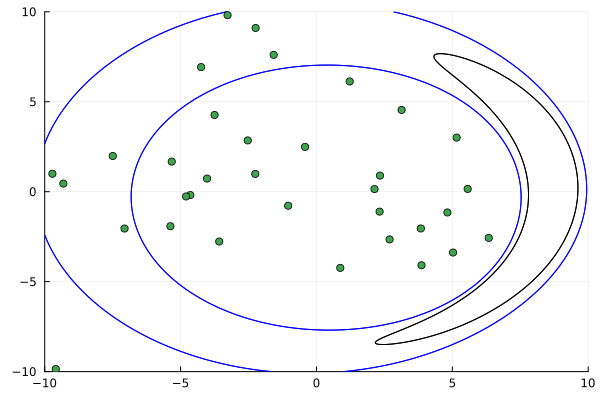

In [8]:
using Plots

function make_contour_plot(B::Polynomial, limits ::Tuple{Float64,Float64}, clr::String; x3_val=0.0,x4_val=0.0)
    x = range(limits[1], limits[2], length=500)
    y = range(limits[1], limits[2], length=500)
    my_fun(xa::Float64,ya::Float64) = B([xa, ya, x3_val, x4_val])
    z = @.my_fun(x', y)
    contour!(x, y, z,levels=[0.0, 0.0], color=clr, colorbar=false)
end

limits=(-10., 10.)
plot(xlims = limits, ylims = limits)
# make_contour_plot(g, limits,"red") 
make_contour_plot(B_1, limits, "black")
make_contour_plot(B_2, limits, "blue")

plot!([x1 for (x1,_) in test_pts], [x2 for (_, x2) in test_pts], seriestype=:scatter, labels=false)


In [9]:
using LaTeXStrings
function circleShape(x,y, r)
    θ = LinRange(0, 2*π, 500)
    x .+ r*cos.(θ), y .+ r*sin.(θ)
end
function plot_ics_region(limits::Tuple{Float64,Float64}, all_barriers::Vector{<:Polynomial}; δ = 0.5, x3_val=π/2,x4_val=0.)
    plot(xlims=limits, ylims=limits)
    rectangle(w, h, x, y) = Shape(x .+ [0,w,w,0], y .+ [0,0,h,h])
    for x in limits[1]:δ:limits[2]
        for y in limits[1]:δ:limits[2]
           if (any([ B(x, y, x3_val, x4_val) <= 0. for B in all_barriers]))
              plot!(rectangle(δ, δ, x-δ, y-δ), label=false, fill=:green, opacity=0.5,linecolor=:green)
           end
        end
    end
    plot!(circleShape(0,0,1.), seriestype =[:shape], lw=0.5, c=:black, linecolor=:black, legend=false, aspectratio=1  )
    plot!(xlims=limits, ylims=limits)
end

plot_ics_region (generic function with 1 method)

In [10]:
all_barriers = [B_1, B_2]

2-element Vector{Polynomial{DynamicPolynomials.Commutative{DynamicPolynomials.CreationOrder}, Graded{LexOrder}, Float64}}:
 1.3659398991070242 + 0.015606790904070468x₄ - 0.7060233308900625x₃ + 0.011186336192959714x₂ - 0.06575797916616885x₁ + 0.0023125473283748905x₄² + 0.04635087121429226x₃x₄ + 0.21122583945905707x₃² - 0.008997460453984422x₂x₄ - 0.01684541185580353x₂x₃ - 0.033285533144532226x₂² + 0.0008453661940477645x₁x₄ + 0.05529914528074405x₁x₃ - 0.0018733329944035184x₁x₂ - 0.027954390857060255x₁² + 8.753966951168561e-5x₄³ + 0.0022600807464503276x₃x₄² + 0.015581146889936824x₃²x₄ + 0.11185561949353313x₃³ - 0.000453370246782655x₂x₄² + 0.0024257800395199487x₂x₃x₄ + 0.012286042492493893x₂x₃² - 0.0009892260034489301x₂²x₄ + 0.010747940784110439x₂²x₃ - 8.224248425020186e-5x₂³ - 0.00011068158651841552x₁x₄² - 0.0017295202956414974x₁x₃x₄ - 0.028518874936098424x₁x₃² + 0.0002361065813040076x₁x₂x₄ + 0.00033056851297356683x₁x₂x₃ + 0.0005843701650455644x₁x₂² - 0.0009079335233545582x₁²x₄ + 0.0090618

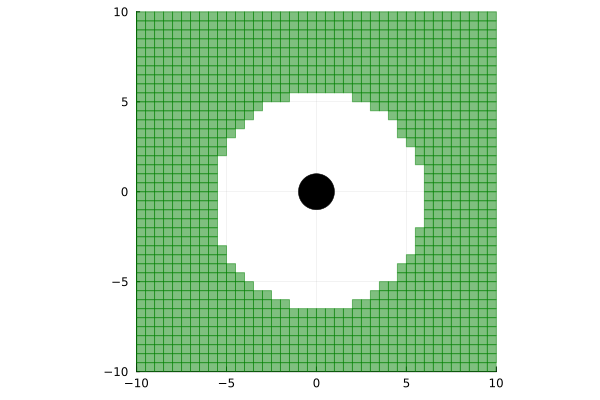

In [11]:
plot_ics_region((-10.0, 10.0), all_barriers; x3_val=2.,x4_val=0)

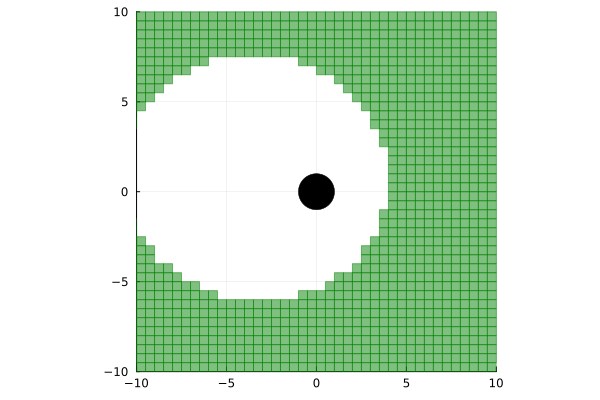

In [12]:
plot_ics_region((-10.0, 10.0), all_barriers; x3_val=-2.,x4_val=0)

Simulation finished
minimum recentered barrier value = -9.836166157575809
minimum true obstacle distance = 11.487379373709876
mean tracking error = 9.325273018852114
max tracking error = 15.638000418560127
number of barrier overrides = 21
Animation saved to figures/repulsive_hybrid_dubins_moving_obstacle.gif


[ Info: Saved animation to /Users/rameez/workspace/moving_obs_barrier/figures/repulsive_hybrid_dubins_moving_obstacle.gif


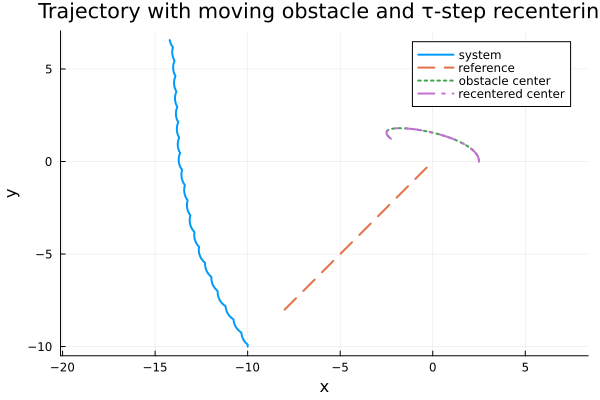

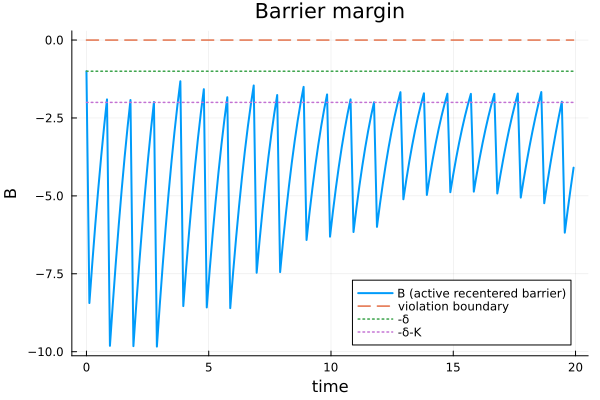

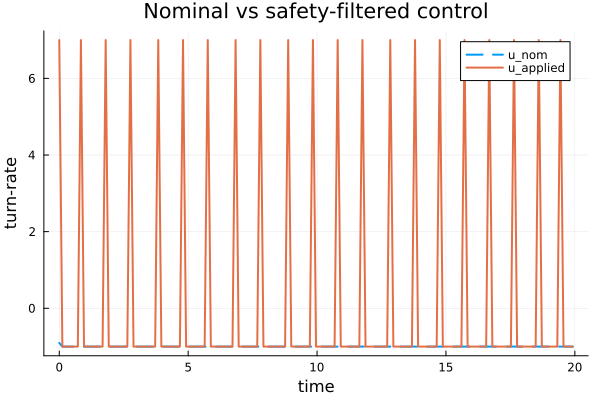

In [14]:
include("Repulsive_hybrid_dubins_recenter_fix.jl")
barrier_controls = [U[1][1], U[2][1]]
τ_steps_run = @isdefined(τ_steps) ? τ_steps : 1

res = run_repulsive_hybrid_dubins_demo(
    all_barriers;
    v,
    τ_steps=τ_steps_run,
    dt=τ,
    T=20.0,
    k_override=K,
    δ,
    barrier_controls=barrier_controls,
    umin=minimum(barrier_controls),
    umax=maximum(barrier_controls),
 )
display(res.p_traj); display(res.p_B); display(res.p_u)